<a href="https://colab.research.google.com/github/prathyusha2020/AAIS_322-Natural-Language-Processing-and-Computer-Vision/blob/main/Interactive_Session_2_0_23_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AAIS 322: Natural Language Process and Computer Vision

##Module 1 Session 2 topic: Text Processing with python

**Topics covered**

1. Regular Expressions
2. Text Normalization
3. Tokenization
4. Stemming
5. Lemmatization
6. A configurable end-to-end pipeline
7. Proof that preprocessing choices change model accuracy

## Lets take a small problem, can u differentiate between these 4 words:
##• woodchuck
##• woodchucks
##• Woodchuck
##• Woodchucks

In [46]:
!pip install nltk spacy scikit-learn pandas regex

In [47]:
import re

text = "The woodchuck ate. Two woodchucks ran. Woodchuck sat. Woodchucks, hi!"

In [48]:
print(text)
print("text")

The woodchuck ate. Two woodchucks ran. Woodchuck sat. Woodchucks, hi!
text


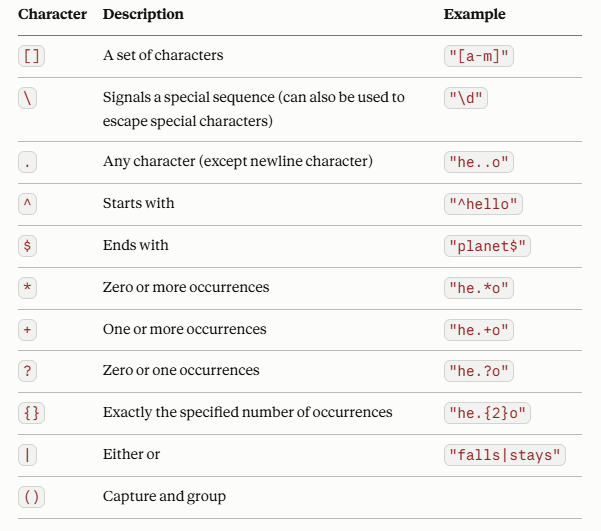

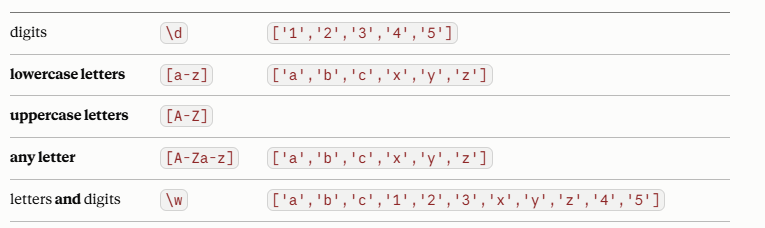

In [66]:
import re

txt = "The rain in Spain falls mainly in the plain!"
print("txt =", txt, "\n")
s = "abc 123 xyz 45"

print("[]  set of chars   ", re.findall(r"[a-z]", txt))
print("\\   special seq    ", re.findall(r"\d", "abc 123 xyz 45"))
print("\\   escape         ", re.findall(r"\.", "1.5 and 2.5"))
print(".   any character  ", re.findall(r"he.o", "hello heyyo he-o hexxo"))
print("^   starts with    ", re.findall(r"^T", txt), re.findall(r"^rain", txt))
print("$   ends with      ", re.findall(r"n!$", txt))
print("*   zero or more   ", re.findall(r"he.*o", "hello heo hexxxxxo"))
print("+   one or more    ", re.findall(r"he.+o", "hello heo hexxxxxo"))
print("?   zero or one    ", re.findall(r"he.?o", "hello heo hexo"))
print("{}  exactly n      ", re.findall(r"he.{2}o", "hello heo hexxo hexxxo"))
print("|   either or      ", re.findall(r"falls|stays", txt))
print("()  capture group  ", re.findall(r"(ai)(n)", txt))

re.findall(r"[A-Za-z]", txt)
re.findall(r"[A-Za-z]",  s)
re.findall(r"[A-Za-z]+", s)

re.findall(r"\d",  s)
re.findall(r"\d+", s)

re.findall(r"\w+", s)

txt = The rain in Spain falls mainly in the plain! 

[]  set of chars    ['h', 'e', 'r', 'a', 'i', 'n', 'i', 'n', 'p', 'a', 'i', 'n', 'f', 'a', 'l', 'l', 's', 'm', 'a', 'i', 'n', 'l', 'y', 'i', 'n', 't', 'h', 'e', 'p', 'l', 'a', 'i', 'n']
\   special seq     ['1', '2', '3', '4', '5']
\   escape          ['.', '.']
.   any character   ['he-o']
^   starts with     ['T'] []
$   ends with       ['n!']
*   zero or more    ['hello heo hexxxxxo']
+   one or more     ['hello heo hexxxxxo']
?   zero or one     ['heo', 'hexo']
{}  exactly n       ['hello', 'hexxo']
|   either or       ['falls']
()  capture group   [('ai', 'n'), ('ai', 'n'), ('ai', 'n'), ('ai', 'n')]


['abc', '123', 'xyz', '45']

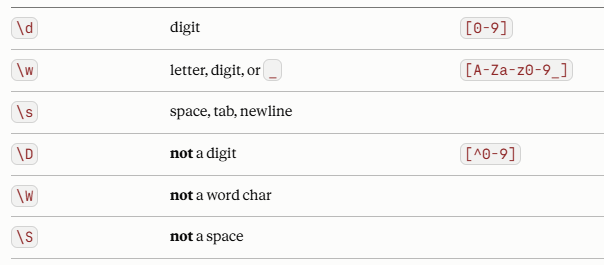

In [67]:
text = "The Woodchucks weren't running. They ran and ate better mice at 5 P.M. Email pdokku@aiuniv.edu"

In [76]:
re.findall(r"\b[w]oodchucks?\b", text)
re.findall(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}", text)
re.findall(r"\d+", text)
re.findall(r"\b[A-Z]\w+", text)

re.search(r"\d+", text).span()
re.sub(r"[\w.%+-]+@[\w.-]+\.\w{2,}", "<EMAIL>", text)
re.split(r"\.\s+", text)

["The Woodchucks weren't running",
 'They ran and ate better mice at 5 P.M',
 'Email pdokku@aiuniv.edu']

In [ ]:
##Example question:  Write Reqular expression for your email address and print it.

##Functions in RE

In [83]:
text = "Order ORD-448192 shipped 2025-03-14. Order ORD-990001 shipped 2025-04-02."

print("findall :", re.findall(r"ORD-\d+", text))          # every match, as strings
print("search  :", re.search(r"ORD-\d+", text))           # first Match object, or None
print("match   :", re.match(r"ORD-\d+", text))            # only if at position 0 -> None here
print("fullmatch:", re.fullmatch(r"ORD-\d+", "ORD-1"))    # entire string must match
print("sub     :", re.sub(r"ORD-\d+", "<ID>", text))      # replace
print("subn    :", re.subn(r"ORD-\d+", "<ID>", text))     # replace + count
print("split   :", re.split(r"\.\s*", text))              # split on delimiter pattern

PAT = re.compile(r"ORD-\d+")                              # compile once, reuse many times
print("compiled:", PAT.findall(text))

findall : ['ORD-448192', 'ORD-990001']
search  : <re.Match object; span=(6, 16), match='ORD-448192'>
match   : None
fullmatch: <re.Match object; span=(0, 5), match='ORD-1'>
sub     : Order <ID> shipped 2025-03-14. Order <ID> shipped 2025-04-02.
subn    : ('Order <ID> shipped 2025-03-14. Order <ID> shipped 2025-04-02.', 2)
split   : ['Order ORD-448192 shipped 2025-03-14', 'Order ORD-990001 shipped 2025-04-02', '']
compiled: ['ORD-448192', 'ORD-990001']


##**Activity: We need to extract the order number from an email.**
The order number follows the format #12345678, where:

"#" is a literal character.
It is followed by exactly 8 digits.

**Example Input:**

email = "Dear Customer, your order number #31886263 has been shipped. Thank you for shopping with us."

**Expected Output:**

'#31886263'

In [84]:
import re

def extract_order_number(email):
    # Define the regex pattern
    pattern = r'#\d{8}'

    # Search for the pattern in the email
    match = re.search(pattern, email)

    # Return the matched order number if found, else return None
    return match.group() if match else None

In [85]:
# Test Case 1: Email contains an order number
email1 = "Dear Customer, your order number #31886263 has been shipped. Thank you for shopping with us."
print(extract_order_number(email1))  # Expected Output: '#31886263'

# Test Case 2: Email does NOT contain an order number
email2 = "Hello, your package is on the way, but we could not find your order number."
print(extract_order_number(email2))  # Expected Output: None

# Test Case 3: Multiple order numbers (should return the first one)
email3 = "Your orders #12345678 and #87654321 are being processed."
print(extract_order_number(email3))  # Expected Output: '#12345678'

# Test Case 4: Order number with more than 8 digits (should not match)
email4 = "Here is your order number #1234567890."
print(extract_order_number(email4))  # Expected Output: None

#31886263
None
#12345678
#12345678


## Text Processing Pipeline


In [15]:
import re, string, unicodedata
from collections import Counter
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk import pos_tag, ngrams

text = "The Woodchucks were RUNNING fast!! They ran and ate 3 better mice."

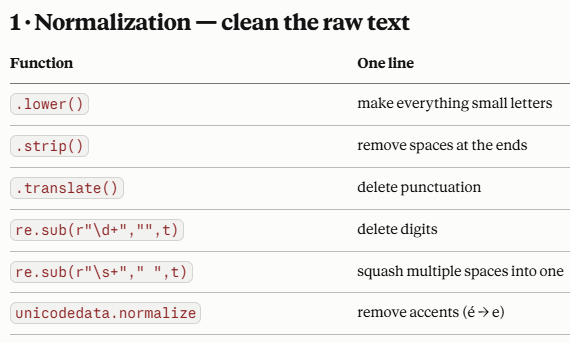

In [90]:
text = "The Woodchucks were RUNNING fast!! They ran and ate 3 better mice."
t = text.lower()
print(t)
t = t.translate(str.maketrans("", "", string.punctuation))
print(t)
t = re.sub(r"\d+", " ", t)
print(t)
t = re.sub(r"\s+", " ", t).strip()
print(t)


the woodchucks were running fast!! they ran and ate 3 better mice.
the woodchucks were running fast they ran and ate 3 better mice
the woodchucks were running fast they ran and ate   better mice
the woodchucks were running fast they ran and ate better mice


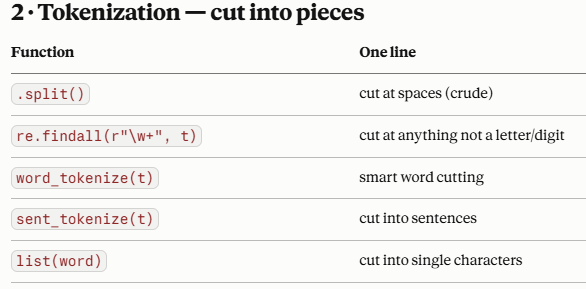



In [24]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [91]:
text = "The Woodchucks were RUNNING fast!! They ran and ate 3 better mice."

print("split      :", text.split())
print("regex      :", re.findall(r"\w+", text))
print("word_tok   :", word_tokenize(text))
print("sent_tok   :", sent_tokenize(text))
print("chars      :", list("cat"))

split      : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast!!', 'They', 'ran', 'and', 'ate', '3', 'better', 'mice.']
regex      : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', 'They', 'ran', 'and', 'ate', '3', 'better', 'mice']
word_tok   : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'and', 'ate', '3', 'better', 'mice', '.']
sent_tok   : ['The Woodchucks were RUNNING fast!!', 'They ran and ate 3 better mice.']
chars      : ['c', 'a', 't']


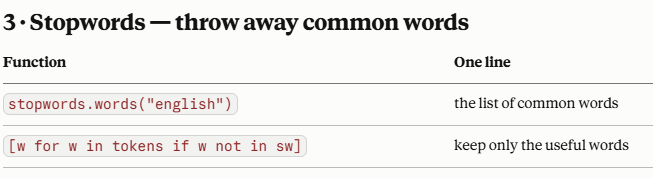

In [27]:
import nltk
nltk.download('stopwords')

tokens = word_tokenize(text) # Define tokens from the 'text' variable

sw = set(stopwords.words("english"))

len(sw)
print("count    :", len(sw))

sorted(sw)[:10]
print("sample   :", sorted(sw)[:10])

[w for w in tokens if w not in sw]
print("tokens   :", tokens)
print("removed  :", [w for w in tokens if w not in sw])
print("dropped  :", [w for w in tokens if w in sw])

count    : 198
sample   : ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']
tokens   : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'and', 'ate', '3', 'better', 'mice', '.']
removed  : ['The', 'Woodchucks', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'ate', '3', 'better', 'mice', '.']
dropped  : ['were', 'and']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


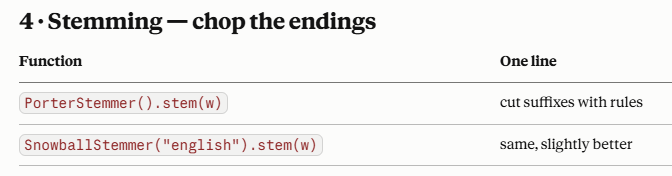

In [29]:
p = PorterStemmer()
for w in ["studies","happiness","university","universe","flies","caring"]:
    print(f"  {w:12} -> {p.stem(w)}")

  studies      -> studi
  happiness    -> happi
  university   -> univers
  universe     -> univers
  flies        -> fli
  caring       -> care


In [34]:
from nltk.stem import PorterStemmer

p = PorterStemmer()

print("tokens  :", tokens)
print("porter  :", [p.stem(w) for w in tokens])


tokens  : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'and', 'ate', '3', 'better', 'mice', '.']
porter  : ['the', 'woodchuck', 'were', 'run', 'fast', '!', '!', 'they', 'ran', 'and', 'ate', '3', 'better', 'mice', '.']


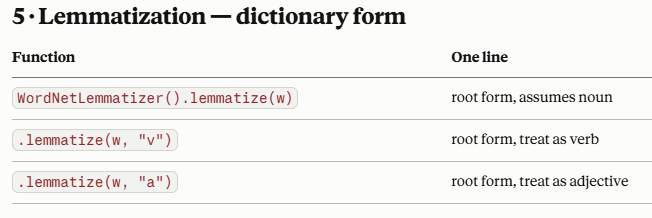

In [35]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [36]:
from nltk.stem import WordNetLemmatizer

wnl = WordNetLemmatizer()

print("tokens :", tokens)
print("noun   :", [wnl.lemmatize(w) for w in tokens])
print("verb   :", [wnl.lemmatize(w, "v") for w in tokens])
print("adj    :", [wnl.lemmatize(w, "a") for w in tokens])
print()
print("mice   :", wnl.lemmatize("mice"))
print("better :", wnl.lemmatize("better", "a"))

tokens : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'and', 'ate', '3', 'better', 'mice', '.']
noun   : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'and', 'ate', '3', 'better', 'mouse', '.']
verb   : ['The', 'Woodchucks', 'be', 'RUNNING', 'fast', '!', '!', 'They', 'run', 'and', 'eat', '3', 'better', 'mice', '.']
adj    : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'and', 'ate', '3', 'good', 'mice', '.']

mice   : mouse
better : good


##6 · POS tagging
Labels every word with its grammatical type :noun, verb, adjective.

example case: It reads the context, not just the word, so fast in "ran fast" gets tagged adverb while fast in "a fast car" gets adjective. The lemmatizer needs this to give correct answers.

In [42]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
#nltk.download('averaged_perceptron_tagger')- old

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [92]:

from nltk import pos_tag

tags = pos_tag(tokens)

print("tokens :", tokens)
print("tags   :", tags)
print()
for w, t in tags:
    print(f"  {w:12} -> {t}")

tokens : ['The', 'Woodchucks', 'were', 'RUNNING', 'fast', '!', '!', 'They', 'ran', 'and', 'ate', '3', 'better', 'mice', '.']
tags   : [('The', 'DT'), ('Woodchucks', 'NNP'), ('were', 'VBD'), ('RUNNING', 'NNP'), ('fast', 'RB'), ('!', '.'), ('!', '.'), ('They', 'PRP'), ('ran', 'VBD'), ('and', 'CC'), ('ate', 'JJ'), ('3', 'CD'), ('better', 'JJR'), ('mice', 'NN'), ('.', '.')]

  The          -> DT
  Woodchucks   -> NNP
  were         -> VBD
  RUNNING      -> NNP
  fast         -> RB
  !            -> .
  !            -> .
  They         -> PRP
  ran          -> VBD
  and          -> CC
  ate          -> JJ
  3            -> CD
  better       -> JJR
  mice         -> NN
  .            -> .


In [94]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

wnl = WordNetLemmatizer()

def pw(tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB,
            "N": wordnet.NOUN, "R": wordnet.ADV}.get(tag[0], wordnet.NOUN)

print("smart lemma:", [wnl.lemmatize(w, pw(t)) for w, t in tags])

smart lemma: ['The', 'Woodchucks', 'be', 'RUNNING', 'fast', '!', '!', 'They', 'run', 'and', 'ate', '3', 'good', 'mouse', '.']


## 7 · N-grams and frequency

N-grams glue neighbouring words into pairs or triples, so word order survives. Without them, "not good" becomes two unrelated features and the meaning is lost. Frequency counting tells you which words dominate a document.


example: "not good"	      = not, good
example: "good, not bad"  =	good, not, bad

In [44]:
from nltk import ngrams
from collections import Counter

print("bigrams :", list(ngrams(tokens, 2))[:4])
print("trigrams:", list(ngrams(tokens, 3))[:3])
print("how many:", len(list(ngrams(tokens, 2))))
print()
print("common  :", Counter(tokens).most_common(3))
print("unique  :", len(set(tokens)), "of", len(tokens))

bigrams : [('The', 'Woodchucks'), ('Woodchucks', 'were'), ('were', 'RUNNING'), ('RUNNING', 'fast')]
trigrams: [('The', 'Woodchucks', 'were'), ('Woodchucks', 'were', 'RUNNING'), ('were', 'RUNNING', 'fast')]
how many: 14

common  : [('!', 2), ('The', 1), ('Woodchucks', 1)]
unique  : 14 of 15


In [ ]:
import nltk

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'movie_reviews']:
    nltk.download(pkg, quiet=True)

## Try Out activity



In [ ]:
import nltk

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'movie_reviews']:
    nltk.download(pkg, quiet=True)

In [ ]:
raw_text = raw = """<p>OMG!!! I ABSOLUTELY loved this laptop 😍 Ordered ORD-772341 on 2025-06-14
and it arrived sooooo fast. Battery lasts 12 hours &amp; the screen is gorgeous.
Contact me at riya.sharma@techmail.co.in or call (931) 555-0177.</p>
<p>BUT... my friend's unit was NOT good. It didn't charge, they ran 3 tests and
the studies showed better results were impossible. Full review:
https://reviews.example.com/laptop?id=88 -- would'nt buy again tbh.</p>"""

In [ ]:
import re, string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ngrams
from collections import Counter

t = raw
# 1 ── remove noise
t = re.sub(r"<[^>]+>", " ", t)
t = re.sub(r"...", " ", t)      # your turn
print("1 CLEAN:", t)

# 2 ── normalize
# 3 ── tokenize
# 4 ── stopwords
# 5-6 ── pos tag + lemmatize
# 7-8 ── counts + bigrams